# Fagprojekt

In [29]:
from pathlib import Path
import os

import numpy as np
import vedo
from vedo import settings
from PIL import Image
from skimage.measure import label, regionprops

from skimage import io
from skimage.filters import threshold_multiotsu, threshold_otsu

import torch
from transformers import AutoImageProcessor, AutoModel
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from scipy import ndimage
from sklearn.metrics.pairwise import cosine_similarity
import math

from dataclasses import asdict, dataclass
from pathlib import Path
import json
import argparse
from PIL import Image, ImageDraw
from vtkmodules.vtkRenderingCore import vtkCoordinate
import tempfile

from types import SimpleNamespace
import tifffile

settings.default_backend = "vtk"

In [30]:
VIEWS = [
    ("1", "+X", np.array([1, 0, 0]), np.array([0, 0, 1])),
    ("2", "-X", np.array([-1, 0, 0]), np.array([0, 0, 1])),
    ("3", "+Y", np.array([0, 1, 0]), np.array([0, 0, 1])),
    ("4", "-Y", np.array([0, -1, 0]), np.array([0, 0, 1])),
    ("5", "+Z", np.array([0, 0, 1]), np.array([0, 1, 0])),
    ("6", "-Z", np.array([0, 0, -1]), np.array([0, 1, 0])),]

ANGLE_TO_INDEX = {
    "+X": 1,
    "-X": 2,
    "+Y": 3,
    "-Y": 4,
    "+Z": 5,
    "-Z": 6,
}

angles = ["+X", "-X", "+Y", "-Y", "+Z", "-Z"]

ANGLE_NAMES = ["+X", "-X", "+Y", "-Y", "+Z", "-Z"]

animals = ["AC", "BC", "BF", "BL", "BP", "CF", "GH", "MA", "PP", "WO"]

## Part 1 - Computer grafik

### Segmentation

In [31]:
zoom = 1.2
render_size = (980,980)

In [32]:
def find_input_volumes(in_root: Path) -> list[Path]:
    return sorted(p for p in in_root.rglob("*.tif"))

In [33]:
def segment_largest_component(volume: np.ndarray) -> np.ndarray:
    thresholds = threshold_otsu(volume)

    # regions = np.digitize(volume,bins=thresholds)

    # mask = regions == 1

    mask = volume > thresholds

    mask = ndimage.binary_dilation(mask,iterations=5)
    mask = ndimage.binary_fill_holes(mask)

    labeled, num = ndimage.label(mask)

    sizes = ndimage.sum_labels(volume, labeled, index=np.arange(1, num + 1))
    largest = int(np.argmax(sizes) + 1)

    mask = labeled == largest

    # returns segmented mask

    return mask

In [34]:
def render_views(
    clean_volume: np.ndarray,
    out_dir: Path,
    base_name: str,
) -> dict[str, object]:
    vol = vedo.Volume(clean_volume)
    xmin, xmax, ymin, ymax, zmin, zmax = vol.bounds()
    center = np.array([(xmin + xmax) / 2, (ymin + ymax) / 2, (zmin + zmax) / 2], dtype=float)
    diag = np.linalg.norm([xmax - xmin, ymax - ymin, zmax - zmin])
    distance = max(diag * 1.5, 1.0)
    camera_views: list[dict[str, object]] = []

    plotter = vedo.Plotter(size=render_size, offscreen=True, bg="white")
    try:
        for idx, label, direction, view_up in VIEWS:
            plotter.clear()
            plotter.show(vol, resetcam=True, zoom=zoom)

            cam = plotter.camera
            cam.SetFocalPoint(*center)
            cam.SetPosition(*(center + direction * distance))
            cam.SetViewUp(*view_up)
            plotter.renderer.ResetCameraClippingRange()

            out_path = out_dir / f"{base_name}_{idx}_{label}.png"
            plotter.screenshot(str(out_path))
            cam_pos = (center + direction * distance).tolist()
            camera_views.append(
                {
                    "view_index": int(idx),
                    "angle": label,
                    "direction": direction.astype(float).tolist(),
                    "view_up": view_up.astype(float).tolist(),
                    "camera_position": cam_pos,
                    "camera_focal_point": center.astype(float).tolist(),
                    "output_image": str(out_path),
                }
            )
    finally:
        plotter.close()

    return {
        "bounds_xyzxyz": [float(xmin), float(xmax), float(ymin), float(ymax), float(zmin), float(zmax)],
        "volume_center_xyz": center.astype(float).tolist(),
        "camera_distance": float(distance),
        "camera_views": camera_views,
    }

In [35]:
def process_volume(in_path: Path, in_root: Path, out_root: Path) -> Path:
    rel_parent = in_path.parent.relative_to(in_root)
    out_dir = out_root / rel_parent / in_path.stem
    out_dir.mkdir(parents=True, exist_ok=True)

    data = vedo.load(str(in_path)).tonumpy()
    mask = segment_largest_component(data)

    # Save mask
    np.savez_compressed(out_dir / "mask.npz", mask=mask)

    clean_data = np.zeros_like(data)
    clean_data[mask] = data[mask]
    render_meta = render_views(clean_data, out_dir=out_dir, base_name=in_path.stem)

    # Voxel axis convention for numpy volume arrays from vedo in this project: [x, y, z].
    shape_xyz = [int(data.shape[0]), int(data.shape[1]), int(data.shape[2])]
    shape_zyx = [shape_xyz[2], shape_xyz[1], shape_xyz[0]]

    metadata = {
        "source_path": str(in_path),
        "output_dir": str(out_dir),
        "volume_shape": shape_xyz,  # Backward-compatible alias; treat as xyz.
        "volume_shape_zyx": shape_zyx,
        "volume_shape_xyz": shape_xyz,
        "voxel_axis_order": "xyz",
        "kept_voxels": int(mask.sum()),
        "total_voxels": int(mask.size),
        "mask_fill_ratio": float(mask.sum() / max(mask.size, 1)),
        "render_geometry": render_meta,
    }
    (out_dir / "metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
    return out_dir

In [36]:
input_root = Path("data/original_photos")
output_root = Path("data/test/segmented")

volumes = find_input_volumes(input_root)

In [37]:
#process_volume(volumes[11*3], input_root, output_root)

In [38]:
for i, f in enumerate(volumes[::11]):
    print(f"Processing {i+1}/{len(volumes)}:", f.name)
    process_volume(f, input_root, output_root)

Processing 1/110: bcrick_1_000.tif


KeyboardInterrupt: 

### Display annotations

In [ ]:
# Loading annotations
path_anno = Path("Annoteringer/annotations_output/image_annotations.json")

annotations = json.loads(path_anno.read_text(encoding="utf-8"))

In [ ]:
def patch_from_pixel(
    x: float,
    y: float,
    img_w: int,
    img_h: int,
    patch_size: int,
) -> dict[str, float | int]:
    # Clip to the cropped patch grid (img // patch_size) that token extraction uses.
    col = int(np.clip(x // patch_size, 0, img_w // patch_size - 1))
    row = int(np.clip(y // patch_size, 0, img_h // patch_size - 1))

    x0 = col * patch_size
    y0 = row * patch_size
    x1 = min(x0 + patch_size - 1, img_w - 1)
    y1 = min(y0 + patch_size - 1, img_h - 1)

    center_x = x0 + (x1 - x0 + 1) / 2.0
    center_y = y0 + (y1 - y0 + 1) / 2.0

    return {
        "patch_col": col,
        "patch_row": row,
        "patch_x0": int(x0),
        "patch_y0": int(y0),
        "patch_x1": int(x1),
        "patch_y1": int(y1),
        "patch_center_x": float(center_x),
        "patch_center_y": float(center_y),
    }

In [ ]:
def get_head_information(in_path: Path, 
                         in_root: Path, 
                         out_root: Path, 
                         annotation_xyz: list[int],
) -> dict[str, tuple[float, float]]:
    
    rel_parent = in_path.parent.relative_to(in_root)
    out_dir = out_root / rel_parent / in_path.stem
    out_dir.mkdir(parents=True, exist_ok=True)

    mask_path = out_root.parent / "segmented" / rel_parent / in_path.stem / "mask.npz"

    volume = vedo.load(str(in_path)).tonumpy()
    mask = np.load(mask_path)["mask"]
    vol = vedo.Volume(volume * mask)
    world_point = np.array(annotation_xyz, dtype=float)


    xmin, xmax, ymin, ymax, zmin, zmax = vol.bounds()
    center = np.array([(xmin + xmax) / 2, (ymin + ymax) / 2, (zmin + zmax) / 2], dtype=float)
    diag = np.linalg.norm([xmax - xmin, ymax - ymin, zmax - zmin])
    distance = max(diag * 1.5, 1.0)

    out = {}

    plotter = vedo.Plotter(size=render_size, offscreen=True)

    for _, label, direction, view_up in VIEWS:
        plotter.clear()
        plotter.show(vol, resetcam=True, zoom=zoom)

        cam = plotter.camera
        cam.SetFocalPoint(*center)
        cam.SetPosition(*(center + direction * distance))
        cam.SetViewUp(*view_up)
        plotter.renderer.ResetCameraClippingRange()
        plotter.render()

        c = vtkCoordinate()
        c.SetCoordinateSystemToWorld()
        c.SetValue(*world_point)

        x, y = c.GetComputedDoubleDisplayValue(plotter.renderer)

        px = float(x)
        py = float(render_size[1] - y)

        patch = patch_from_pixel(px,py,render_size[0],render_size[1],patch_size)

        out[label] = (px, py)

        out[label] = {
                "head_x": round(px, 3),
                "head_y": round(py, 3),
                "image_width": render_size[0],
                "image_height": render_size[1],
                "patch_size": patch_size,
                "patch_col": patch["patch_col"],
                "patch_row": patch["patch_row"],
                "patch_x0": patch["patch_x0"],
                "patch_y0": patch["patch_y0"],
                "patch_x1": patch["patch_x1"],
                "patch_y1": patch["patch_y1"],
                "patch_center_x": round(float(patch["patch_center_x"]), 3),
                "patch_center_y": round(float(patch["patch_center_y"]), 3),
        }

    plotter.close()

    out_path = out_dir / "head_projection.json"
    with open(out_path, "w") as f:
        json.dump(out, f, indent=2)

    return out

In [ ]:
input_root = Path("data/original_photos")
input_path = Path("data/original_photos/BF/spy_1_000.tif")
output_root = Path("data/test/head_cords")
volumes = find_input_volumes(input_root)

In [ ]:
for i, f in enumerate(volumes[0:3]):
    print(f"Processing {i+1}/{len(volumes)}:", f.name)
    annotation_xyz = annotations[str(f.parts[-2])][str(f.parts[-1])]
    get_head_information(f,input_root,output_root,annotation_xyz)

Processing 1/132: bcrick_1_000.tif
Processing 2/132: bcrick_1_001.tif
Processing 3/132: bcrick_1_002.tif


## Part  2 - Billedanalyse og AI-modeller

In [ ]:
from pathlib import Path
import numpy as np
import vedo
from vtkmodules.vtkRenderingCore import vtkCoordinate

In [ ]:
bg_threshold = 240
fg_patch_ratio = 0.2

In [ ]:
# Loading DinoV3 model

device = "cuda" if torch.cuda.is_available() else "cpu"
model_name = "facebook/dinov3-vits16-pretrain-lvd1689m"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

# DINOv3 sequence is [CLS] + register tokens + patch tokens.
patch_size = int(getattr(model.config, "patch_size", 16))
num_register_tokens = int(getattr(model.config, "num_register_tokens", 0))
num_prefix_tokens = 1 + num_register_tokens  # CLS + register tokens
print(f"patch_size={patch_size} | num_register_tokens={num_register_tokens}")

token_cache = {}

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 1275.02it/s]


patch_size=16 | num_register_tokens=4


In [ ]:
def log(message: str) -> None:
    print(message, flush=True)

In [ ]:
def crop_to_patch_multiple(image: Image.Image, patch_size: int) -> Image.Image:
    # DINOv3 (patch_size=16) needs HxW divisible by patch_size; crop the
    # bottom/right edge so the patch grid lines up with the token grid.
    w, h = image.size
    nw = (w // patch_size) * patch_size
    nh = (h // patch_size) * patch_size
    if nw <= 0 or nh <= 0:
        raise ValueError(f"Image too small for patch_size={patch_size}: {(w, h)}")
    if (nw, nh) == (w, h):
        return image
    return image.crop((0, 0, nw, nh))


def make_foreground_patch_mask(
    image: Image.Image,
    patch_size: int,
    bg_threshold: int,
    fg_patch_ratio: float,
) -> tuple[np.ndarray, int, int]:

    # Finds foreground patches
    img = np.array(image)

    # foreground pixels
    fg_pixel = ~np.all(img > bg_threshold, axis=2)

    h, w = fg_pixel.shape
    grid_h = h // patch_size
    grid_w = w // patch_size

    # reshape into patches and compute foreground fraction per patch
    patches = fg_pixel.reshape(
        grid_h, patch_size,
        grid_w, patch_size
    )

    fg_fraction = patches.mean(axis=(1, 3))

    fg_patch = fg_fraction > fg_patch_ratio

    return fg_patch.ravel(), grid_h, grid_w

In [ ]:
def extract_patch_tokens(
    image_path: Path,
    processor: AutoImageProcessor,
    model: AutoModel,
    patch_size: int,
    num_prefix_tokens: int,
    bg_threshold: int,
    fg_patch_ratio: float,
    device: str,
) -> dict[str, object]:
    parts = image_path.parts
    seg_idx = next(i for i, p in enumerate(parts) if p == "segmented")
    token_dir = Path(*parts[:seg_idx]) / "tokens" / Path(*parts[seg_idx + 1:]).parent / image_path.stem
    token_dir.mkdir(parents=True, exist_ok=True)

    tokens_path  = token_dir / "tokens.npy"
    fg_flat_path = token_dir / "fg_flat.npy"

    if tokens_path.exists() and fg_flat_path.exists():
        log(f"  [tokens] loading cached: {image_path.name}")
        image   = Image.open(image_path).convert("RGB")
        image   = crop_to_patch_multiple(image, patch_size)
        tokens  = np.load(tokens_path)
        fg_flat = np.load(fg_flat_path)
        _, grid_h, grid_w = make_foreground_patch_mask(
            image=image,
            patch_size=patch_size,
            bg_threshold=bg_threshold,
            fg_patch_ratio=fg_patch_ratio,
        )
        return {
            "image":   image,
            "tokens":  tokens,
            "fg_flat": fg_flat,
            "grid_h":  grid_h,
            "grid_w":  grid_w,
        }

    image = Image.open(image_path).convert("RGB")
    image = crop_to_patch_multiple(image, patch_size)

    fg_flat, grid_h, grid_w = make_foreground_patch_mask(
        image=image,
        patch_size=patch_size,
        bg_threshold=bg_threshold,
        fg_patch_ratio=fg_patch_ratio,
    )

    with torch.inference_mode():
        inputs = processor(
            images=image,
            return_tensors="pt",
            do_resize=False,
            do_center_crop=False,
        )
        inputs = {k: v.to(device) for k, v in inputs.items()}
        outputs = model(**inputs)
        # DINOv3 sequence is [CLS] + register tokens + patch tokens, so skip the
        # leading num_prefix_tokens (1 + num_register_tokens) to keep patch tokens only.
        patch_tokens = outputs.last_hidden_state[:, num_prefix_tokens:, :].squeeze(0).detach().cpu().numpy()

    if patch_tokens.shape[0] != grid_h * grid_w:
        raise ValueError(
            f"Patch count mismatch in {image_path}: got {patch_tokens.shape[0]}, expected {grid_h * grid_w}"
        )

    np.save(tokens_path, patch_tokens)
    np.save(fg_flat_path, fg_flat)
    log(f"  [tokens] saved: {image_path.name}")

    return {
        "image":   image,
        "tokens":  patch_tokens,
        "fg_flat": fg_flat,
        "grid_h":  grid_h,
        "grid_w":  grid_w,
    }

In [ ]:
def discover_segmented_individuals(segmented_root: Path, animal: str) -> list[str]:
    species_dir = segmented_root / animal
    if not species_dir.exists():
        return []
    return sorted(p.name for p in species_dir.iterdir() if p.is_dir())

In [ ]:
def extract_patch_tokens_animal(
    segmented_root: Path,
    animal: str,
    processor: AutoImageProcessor,
    model: AutoModel,
    patch_size: int,
    num_prefix_tokens: int,
    bg_threshold: int,
    fg_patch_ratio: float,
    device: str,
) -> None:

    segmented_individuals = discover_segmented_individuals(segmented_root, animal)

    for idx, individual in enumerate(segmented_individuals):
        for angle in angles:
            image_path = segmented_root / animal / individual / f'{individual}_{ANGLE_TO_INDEX[angle]}_{angle}.png'
            extract_patch_tokens(
                    image_path,
                    processor,
                    model,
                    patch_size,
                    num_prefix_tokens,
                    bg_threshold,
                    fg_patch_ratio,
                    device,
            )

    return None

In [ ]:
def build_prototype_animal(
    animal: str,
    tokens_root: Path,
    head_cords_root: Path,
):
    head_cords_lst_animal = discover_segmented_individuals(head_cords_root,animal)

    proto_list = []

    for i, scan_stem in enumerate(head_cords_lst_animal):
        head_info_path = head_cords_root / animal / scan_stem / "head_projection.json"
        print(head_info_path)
        
        if not Path.exists(head_info_path):
            continue
        
        head_info = json.loads(head_info_path.read_text(encoding="utf-8"))

        for angle, angle_info in head_info.items():
            patch_row = int(angle_info["patch_row"])
            patch_col = int(angle_info["patch_col"])

            # Token files are per render image, named by scan + angle
            # e.g. data/test/tokens/AC/bcrick_1_000/bcrick_1_000_1_+X/
            token_dir = tokens_root / animal / scan_stem / f"{scan_stem}_{ANGLE_TO_INDEX[angle]}_{angle}"
            tokens_path = token_dir / "tokens.npy"

            if not Path.exists(tokens_path):
                continue

            tokens = np.load(tokens_path)  # (n_patches, embed_dim)
            grid_h = render_size[0]/14
            grid_w = render_size[1]/14

            idx = int(patch_row * grid_w + patch_col)
            proto_list.append(tokens[idx])
            log(f"  [{animal} {angle}] added patch from {scan_stem}")
    
    if not proto_list:
        raise ValueError(f"No prototype vectors could be built for animal '{animal}'")
    
    for v in proto_list:
        print(v.shape)

    prototype_vector = np.mean(proto_list,axis=0)

    np.save(tokens_root / animal / "prototype_vector.npy", prototype_vector)

    return np.mean(proto_list,axis=0)

In [ ]:
def plot_patch_similarity(head_vector, tokens, grid_h=None, grid_w=None):
    sims = cosine_similarity([head_vector], tokens)
    if grid_h is None or grid_w is None:
        side = int(round(np.sqrt(tokens.shape[0])))
        grid_h = grid_w = side
    sim_map = sims.reshape(grid_h, grid_w)
    plt.imshow(sim_map, cmap="jet")
    plt.colorbar()
    plt.title("Patch similarity map")
    plt.axis("off")
    plt.show()

In [ ]:
tokens_root = Path("data/test/tokens")
head_cords_root = Path("data/test/head_cords")

In [28]:
prototype_vector = build_prototype_animal("AC",tokens_root,head_cords_root)

ValueError: No prototype vectors could be built for animal 'AC'

In [226]:
tokens = np.load(r'data\test\tokens\AC\bcrick_1_000\bcrick_1_000_1_+X\tokens.npy')
tokens

array([[ 0.30623603, -0.47103965, -1.9368109 , ..., -0.72083056,
         0.8978351 , -0.79872566],
       [ 0.30793658, -0.5476897 , -1.9600297 , ..., -0.74434876,
         0.8847846 , -0.8070745 ],
       [ 0.22789292, -0.9024062 , -2.362691  , ..., -0.83299303,
         0.8801315 , -0.7810336 ],
       ...,
       [ 2.2456713 ,  0.01139389, -4.2298727 , ..., -0.8229961 ,
         1.7651829 , -0.6615308 ],
       [ 2.2022922 , -0.34908253, -3.6975837 , ..., -1.0168616 ,
         1.8677348 , -1.0203443 ],
       [ 2.395535  , -0.55242825, -3.4492621 , ..., -1.0540719 ,
         1.9728612 , -1.1163254 ]], shape=(4900, 768), dtype=float32)

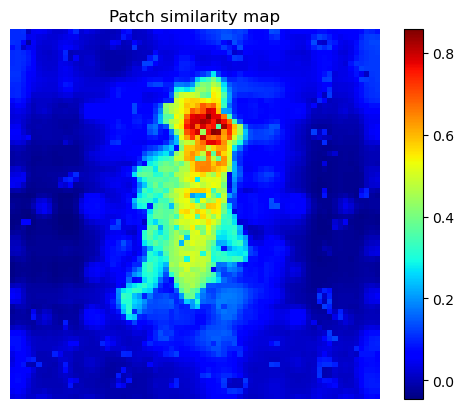

In [227]:
plot_patch_similarity(prototype_vector,tokens)

In [123]:
segmented_root = Path("data/test/segmented")
animal = 'AC'
extract_patch_tokens_animal(segmented_root,animal,processor,model,patch_size,num_prefix_tokens,bg_threshold,fg_patch_ratio,device)

  [tokens] saved: bcrick_1_000_1_+X.png
  [tokens] saved: bcrick_1_000_2_-X.png
  [tokens] saved: bcrick_1_000_3_+Y.png
  [tokens] saved: bcrick_1_000_4_-Y.png
  [tokens] saved: bcrick_1_000_5_+Z.png
  [tokens] saved: bcrick_1_000_6_-Z.png
  [tokens] saved: bcrick_1_001_1_+X.png
  [tokens] saved: bcrick_1_001_2_-X.png
  [tokens] saved: bcrick_1_001_3_+Y.png
  [tokens] saved: bcrick_1_001_4_-Y.png
  [tokens] saved: bcrick_1_001_5_+Z.png
  [tokens] saved: bcrick_1_001_6_-Z.png
  [tokens] saved: bcrick_1_003_1_+X.png
  [tokens] saved: bcrick_1_003_2_-X.png
  [tokens] saved: bcrick_1_003_3_+Y.png
  [tokens] saved: bcrick_1_003_4_-Y.png
  [tokens] saved: bcrick_1_003_5_+Z.png
  [tokens] saved: bcrick_1_003_6_-Z.png
  [tokens] saved: bcrick_1_005_1_+X.png
  [tokens] saved: bcrick_1_005_2_-X.png
  [tokens] saved: bcrick_1_005_3_+Y.png
  [tokens] saved: bcrick_1_005_4_-Y.png
  [tokens] saved: bcrick_1_005_5_+Z.png
  [tokens] saved: bcrick_1_005_6_-Z.png
  [tokens] saved: bcrick_1_007_1_+X.png


In [126]:
path_anno = Path("Annoteringer/annotations_output/image_annotations.json")

annotations = json.loads(path_anno.read_text(encoding="utf-8"))

### Computing cosine similarities

In [26]:
def save_cosine_similarities(tokens_root: Path, animal: str):
    path_prototype = tokens_root / animal / "prototype_vector.npy"
    prototype_vector = np.load(path_prototype)  # (embed_dim,)

    lst_individuals = discover_segmented_individuals(tokens_root, animal)

    for individual in lst_individuals:
        individual_dir = tokens_root / animal / individual

        for angle_dir in sorted(individual_dir.iterdir()):
            if not angle_dir.is_dir():
                continue

            tokens_path  = angle_dir / "tokens.npy"
            fg_flat_path = angle_dir / "fg_flat.npy"
            out_path     = angle_dir / "cosine_similarity.npy"

            if not tokens_path.exists() or not fg_flat_path.exists():
                log(f"  [{animal} {individual}] skipping {angle_dir.name} — missing tokens or fg_flat")
                continue

            tokens  = np.load(tokens_path)   # (n_patches, embed_dim)
            fg_flat = np.load(fg_flat_path)  # (n_patches,) bool

            sims = np.full(tokens.shape[0], np.nan)
            sims[fg_flat] = cosine_similarity(
                tokens[fg_flat],
                prototype_vector.reshape(1, -1),
            ).squeeze(1)

            np.save(out_path, sims)
            log(f"  [{animal} {individual}] saved cosine similarities: {angle_dir.name}")

In [27]:
def save_top_k_patches(tokens_root: Path, animal: str, k: int):
    lst_individuals = discover_segmented_individuals(tokens_root, animal)

    for individual in lst_individuals:
        individual_dir = tokens_root / animal / individual

        for angle_dir in sorted(individual_dir.iterdir()):
            if not angle_dir.is_dir():
                continue

            sims_path = angle_dir / "cosine_similarity.npy"
            out_path  = angle_dir / "top_k_patches.json"

            if not sims_path.exists():
                log(f"  [{animal} {individual}] skipping {angle_dir.name} — cosine_similarity.npy not found")
                continue

            sims    = np.load(sims_path)        # (n_patches,) with nan for background
            fg_mask = ~np.isnan(sims)           # foreground indices

            fg_indices = np.where(fg_mask)[0]
            fg_sims    = sims[fg_indices]

            if len(fg_indices) == 0:
                log(f"  [{animal} {individual}] skipping {angle_dir.name} — no foreground patches")
                continue

            actual_k      = min(k, len(fg_indices))
            top_k_order   = np.argsort(fg_sims)[::-1][:actual_k]
            top_k_flat    = fg_indices[top_k_order]

            grid_w = int(render_size[0] // patch_size)

            top_k_patches = []
            for rank, flat_idx in enumerate(top_k_flat):
                row = int(flat_idx // grid_w)
                col = int(flat_idx % grid_w)
                top_k_patches.append({
                    "rank":            rank,
                    "flat_idx":        int(flat_idx),
                    "patch_row":       row,
                    "patch_col":       col,
                    "patch_x0":        col * patch_size,
                    "patch_y0":        row * patch_size,
                    "patch_x1":        col * patch_size + (patch_size - 1),
                    "patch_y1":        row * patch_size + (patch_size - 1),
                    "cosine_similarity": float(sims[flat_idx]),
                })

            out_path.write_text(
                json.dumps({"k": actual_k, "patches": top_k_patches}, indent=2),
                encoding="utf-8",
            )
            log(f"  [{animal} {individual}] saved top-{actual_k} patches: {angle_dir.name}")

In [28]:
def build_rays_from_top_k_patches(
    top_k_patches_path: Path,
    image_w: int,
    image_h: int,
    cam_pos: np.ndarray,
    focal: np.ndarray,
    view_up: np.ndarray,
    fov_y_deg: float,
    patch_size: int = 16,
):
    """
    Loads top_k_patches.json and converts patches into 3D rays.

    Returns:
        origins: (K, 3)
        dirs:    (K, 3)
        meta:    list of patch metadata
    """

    data = json.loads(top_k_patches_path.read_text(encoding="utf-8"))
    patches = data["patches"]

    origins = []
    dirs = []
    meta = []

    for p in patches:
        row = p["patch_row"]
        col = p["patch_col"]

        # convert patch → pixel center
        px = (col + 0.5) * patch_size
        py = (row + 0.5) * patch_size

        # normalize to [0,1]
        nx = px / float(image_w)
        ny = py / float(image_h)

        origin, direction = build_ray_from_pixel(
            nx=nx,
            ny=ny,
            image_w=image_w,
            image_h=image_h,
            cam_pos=cam_pos,
            focal=focal,
            view_up=view_up,
            fov_y_deg=fov_y_deg,
        )

        origins.append(origin)
        dirs.append(direction)

        meta.append({
            "rank": p["rank"],
            "flat_idx": p["flat_idx"],
            "cosine_similarity": p["cosine_similarity"],
            "patch_row": row,
            "patch_col": col,
        })

    return np.asarray(origins), np.asarray(dirs), meta

In [41]:
save_cosine_similarities(tokens_root,"AC")

  [AC bcrick_1_000] saved cosine similarities: bcrick_1_000_1_+X
  [AC bcrick_1_000] saved cosine similarities: bcrick_1_000_2_-X
  [AC bcrick_1_000] saved cosine similarities: bcrick_1_000_3_+Y
  [AC bcrick_1_000] saved cosine similarities: bcrick_1_000_4_-Y
  [AC bcrick_1_000] saved cosine similarities: bcrick_1_000_5_+Z
  [AC bcrick_1_000] saved cosine similarities: bcrick_1_000_6_-Z
  [AC bcrick_1_001] saved cosine similarities: bcrick_1_001_1_+X
  [AC bcrick_1_001] saved cosine similarities: bcrick_1_001_2_-X
  [AC bcrick_1_001] saved cosine similarities: bcrick_1_001_3_+Y
  [AC bcrick_1_001] saved cosine similarities: bcrick_1_001_4_-Y
  [AC bcrick_1_001] saved cosine similarities: bcrick_1_001_5_+Z
  [AC bcrick_1_001] saved cosine similarities: bcrick_1_001_6_-Z
  [AC bcrick_1_003] saved cosine similarities: bcrick_1_003_1_+X
  [AC bcrick_1_003] saved cosine similarities: bcrick_1_003_2_-X
  [AC bcrick_1_003] saved cosine similarities: bcrick_1_003_3_+Y
  [AC bcrick_1_003] saved

In [42]:
save_top_k_patches(tokens_root,"AC",3)

  [AC bcrick_1_000] saved top-3 patches: bcrick_1_000_1_+X
  [AC bcrick_1_000] saved top-3 patches: bcrick_1_000_2_-X
  [AC bcrick_1_000] saved top-3 patches: bcrick_1_000_3_+Y
  [AC bcrick_1_000] saved top-3 patches: bcrick_1_000_4_-Y
  [AC bcrick_1_000] saved top-3 patches: bcrick_1_000_5_+Z
  [AC bcrick_1_000] saved top-3 patches: bcrick_1_000_6_-Z
  [AC bcrick_1_001] saved top-3 patches: bcrick_1_001_1_+X
  [AC bcrick_1_001] saved top-3 patches: bcrick_1_001_2_-X
  [AC bcrick_1_001] saved top-3 patches: bcrick_1_001_3_+Y
  [AC bcrick_1_001] saved top-3 patches: bcrick_1_001_4_-Y
  [AC bcrick_1_001] saved top-3 patches: bcrick_1_001_5_+Z
  [AC bcrick_1_001] saved top-3 patches: bcrick_1_001_6_-Z
  [AC bcrick_1_003] saved top-3 patches: bcrick_1_003_1_+X
  [AC bcrick_1_003] saved top-3 patches: bcrick_1_003_2_-X
  [AC bcrick_1_003] saved top-3 patches: bcrick_1_003_3_+Y
  [AC bcrick_1_003] saved top-3 patches: bcrick_1_003_4_-Y
  [AC bcrick_1_003] saved top-3 patches: bcrick_1_003_5_

### Rays

In [29]:
def load_camera_by_angle(segmented_meta: Path) -> dict[str, dict[str, object]]:
    d = json.loads(segmented_meta.read_text(encoding="utf-8"))
    views = d.get("render_geometry", {}).get("camera_views", [])
    out: dict[str, dict[str, object]] = {}
    for v in views:
        angle = v.get("angle")
        if angle in ANGLE_NAMES:
            out[angle] = v
    return out

In [30]:
def camera_basis(cam_pos: np.ndarray, focal: np.ndarray, view_up: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    f = focal - cam_pos
    f = f / max(np.linalg.norm(f), 1e-12)
    u0 = view_up / max(np.linalg.norm(view_up), 1e-12)
    r = np.cross(f, u0)
    r = r / max(np.linalg.norm(r), 1e-12)
    u = np.cross(r, f)
    u = u / max(np.linalg.norm(u), 1e-12)
    return r, u, f

In [31]:
def build_ray_from_pixel(
    nx: float,
    ny: float,
    image_w: int,
    image_h: int,
    cam_pos: np.ndarray,
    focal: np.ndarray,
    view_up: np.ndarray,
    fov_y_deg: float,
) -> tuple[np.ndarray, np.ndarray]:
    x_ndc = (nx - 0.5) * 2.0
    y_ndc = (0.5 - ny) * 2.0
    aspect = float(image_w) / max(float(image_h), 1.0)
    tan_half = np.tan(np.deg2rad(fov_y_deg) * 0.5)

    d_cam = np.array([x_ndc * aspect * tan_half, y_ndc * tan_half, 1.0], dtype=float)
    d_cam = d_cam / max(np.linalg.norm(d_cam), 1e-12)

    r, u, f = camera_basis(cam_pos, focal, view_up)
    d_world = d_cam[0] * r + d_cam[1] * u + d_cam[2] * f
    d_world = d_world / max(np.linalg.norm(d_world), 1e-12)
    return cam_pos, d_world

In [32]:
def triangulate_rays(origins: list[np.ndarray], dirs: list[np.ndarray]) -> tuple[np.ndarray, float]:
    A = np.zeros((3, 3), dtype=float)
    b = np.zeros(3, dtype=float)

    for o, d in zip(origins, dirs):
        d = d / max(np.linalg.norm(d), 1e-12)
        M = np.eye(3) - np.outer(d, d)
        A += M
        b += M @ o

    p = np.linalg.solve(A + np.eye(3) * 1e-9, b)

    dists = []
    for o, d in zip(origins, dirs):
        d = d / max(np.linalg.norm(d), 1e-12)
        dists.append(float(np.linalg.norm(np.cross(p - o, d))))

    return p, float(np.mean(dists))

In [33]:
camera_fov_deg = 30.0

In [34]:
def point_ray_distance(p: np.ndarray, o: np.ndarray, d: np.ndarray) -> float:
    d = d / max(np.linalg.norm(d), 1e-12)
    return float(np.linalg.norm(np.cross(p - o, d)))

In [35]:
def build_rays_from_individual(segmented_root: Path, tokens_root: Path, animal: str, individual: str):
    seg_meta = segmented_root / animal / individual / "metadata.json"

    cam_by_angle = load_camera_by_angle(seg_meta)

    origins = []
    dirs = []
    weights = []
    per_angle = {}
    volume_shape_xyz = None

    for i, angle in enumerate(angles):
        cam = cam_by_angle[angle]


        print(angle, cam["camera_position"])

        cam_pos = np.array(cam["camera_position"], dtype=float)
        focal = np.array(cam["camera_focal_point"], dtype=float)
        view_up = np.array(cam["view_up"], dtype=float)

        angles_root = tokens_root / animal

        angle_paths = discover_segmented_individuals(angles_root, individual)

        for path in angle_paths:
            json_path = angles_root / individual / path / "top_k_patches.json"
            top_k_json = json.loads(json_path.read_text(encoding="utf-8"))['patches']

            for patch in top_k_json:
                nx = ((patch['patch_x0'] + patch['patch_x1']) / 2.0) / render_size[0]
                ny = ((patch['patch_y0'] + patch['patch_y1']) / 2.0) / render_size[1]

                image_w = render_size[0]
                image_h = render_size[1]

                origin, direction = build_ray_from_pixel(
                    nx,
                    ny,
                    image_w,
                    image_h,
                    cam_pos,
                    focal,
                    view_up,
                    fov_y_deg=30,
                )

                origins.append(origin)
                dirs.append(direction)

    return origins, dirs

In [36]:
def build_rays_from_individual(segmented_root: Path, tokens_root: Path, animal: str, individual: str):
    seg_meta = segmented_root / animal / individual / "metadata.json"
    cam_by_angle = load_camera_by_angle(seg_meta)

    origins = []
    dirs = []

    for angle in angles:
        if angle not in cam_by_angle:
            continue

        cam = cam_by_angle[angle]
        cam_pos = np.array(cam["camera_position"], dtype=float)
        focal   = np.array(cam["camera_focal_point"], dtype=float)
        view_up = np.array(cam["view_up"], dtype=float)

        # Find the folder matching this specific angle
        angle_idx = ANGLE_TO_INDEX[angle]
        angle_dir = tokens_root / animal / individual / f"{individual}_{angle_idx}_{angle}"
        json_path = angle_dir / "top_k_patches.json"

        if not json_path.exists():
            log(f"  [{animal} {individual} {angle}] top_k_patches.json not found")
            continue

        patches = json.loads(json_path.read_text(encoding="utf-8"))["patches"]

        for patch in patches:
            nx = ((patch["patch_x0"] + patch["patch_x1"]) / 2.0) / render_size[0]
            ny = ((patch["patch_y0"] + patch["patch_y1"]) / 2.0) / render_size[1]

            origin, direction = build_ray_from_pixel(
                nx=nx,
                ny=ny,
                image_w=render_size[0],
                image_h=render_size[1],
                cam_pos=cam_pos,
                focal=focal,
                view_up=view_up,
                fov_y_deg=30,
            )

            origins.append(origin)
            dirs.append(direction)

        print(angle, cam["camera_position"], f"— {len(patches)} patches")

    return origins, dirs

In [37]:
def ransac_fuse(
    origins: list[np.ndarray],
    dirs: list[np.ndarray],
    threshold: float,
    refine_iters: int,
) -> dict | None:
    if len(origins) < 2:
        return None

    best: tuple[int, np.ndarray, list[int]] | None = None

    for i in range(len(origins)):
        for j in range(i + 1, len(origins)):
            p, _ = triangulate_rays(
                [origins[i], origins[j]],
                [dirs[i], dirs[j]],
            )

            inliers = [
                k for k in range(len(origins))
                if point_ray_distance(p, origins[k], dirs[k]) <= threshold
            ]

            if best is None or len(inliers) > best[0]:
                best = (len(inliers), p, inliers)

    if best is None:
        return None

    _, p, inliers = best
    for _ in range(max(0, refine_iters)):
        if len(inliers) < 2:
            break
        p, _ = triangulate_rays(
            [origins[k] for k in inliers],
            [dirs[k] for k in inliers],
        )
        inliers = [
            k for k in range(len(origins))
            if point_ray_distance(p, origins[k], dirs[k]) <= threshold
        ]

    return {
        "point":     p,
        "inliers":   inliers,
        "n_inliers": len(inliers),
        "threshold": threshold,
    }

In [59]:
tokens_root = Path("data/test/tokens")
segmented_root = Path("data/test/segmented")
animal = "AC"
individual = "bcrick_1_000"

origins, dirs = build_rays_from_individual(segmented_root, tokens_root, animal, individual)

+X [1065.654971206783, 127.5, 255.5] — 3 patches
-X [-810.6549712067831, 127.5, 255.5] — 3 patches
+Y [127.5, 1065.654971206783, 255.5] — 3 patches
-Y [127.5, -810.6549712067831, 255.5] — 3 patches
+Z [127.5, 127.5, 1193.654971206783] — 3 patches
-Z [127.5, 127.5, -682.6549712067831] — 3 patches


In [67]:
result_ransac = ransac_fuse(origins,dirs,10,4)

In [68]:
head_xyz = result_ransac['point']
head_xyz

array([212.34999266, 135.04261267, 366.74538803])

### Rotating

In [38]:
def axis_to_vector(axis: str) -> np.ndarray:
    m = {
        "+X": np.array([1.0, 0.0, 0.0], dtype=float),
        "-X": np.array([-1.0, 0.0, 0.0], dtype=float),
        "+Y": np.array([0.0, 1.0, 0.0], dtype=float),
        "-Y": np.array([0.0, -1.0, 0.0], dtype=float),
        "+Z": np.array([0.0, 0.0, 1.0], dtype=float),
        "-Z": np.array([0.0, 0.0, -1.0], dtype=float),
    }
    return m[axis]

In [39]:
def rotation_matrix_from_vectors(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    a = a.astype(float)
    b = b.astype(float)
    a /= max(np.linalg.norm(a), 1e-12)
    b /= max(np.linalg.norm(b), 1e-12)

    v = np.cross(a, b)
    c = float(np.dot(a, b))
    s = float(np.linalg.norm(v))

    if s < 1e-12:
        if c > 0.0:
            return np.eye(3, dtype=float)
        # 180-degree rotation around any axis orthogonal to a.
        axis = np.array([1.0, 0.0, 0.0], dtype=float)
        if abs(np.dot(axis, a)) > 0.9:
            axis = np.array([0.0, 1.0, 0.0], dtype=float)
        axis = axis - np.dot(axis, a) * a
        axis /= max(np.linalg.norm(axis), 1e-12)
        x, y, z = axis
        return np.array(
            [
                [2 * x * x - 1, 2 * x * y, 2 * x * z],
                [2 * y * x, 2 * y * y - 1, 2 * y * z],
                [2 * z * x, 2 * z * y, 2 * z * z - 1],
            ],
            dtype=float,
        )

    vx = np.array(
        [
            [0.0, -v[2], v[1]],
            [v[2], 0.0, -v[0]],
            [-v[1], v[0], 0.0],
        ],
        dtype=float,
    )
    r = np.eye(3, dtype=float) + vx + (vx @ vx) * ((1.0 - c) / (s * s))
    return r

In [40]:
def rotate_volume(volume: np.ndarray, rot: np.ndarray, order: int) -> np.ndarray:
    # ndimage.affine_transform maps output coords -> input coords.
    # For forward rotation R around center c, use R^-1 and offset c - R^-1 c.
    center = (np.array(volume.shape, dtype=float) - 1.0) / 2.0
    r_inv = rot.T
    offset = center - r_inv @ center
    rotated = ndimage.affine_transform(
        volume,
        matrix=r_inv,
        offset=offset,
        order=order,
        mode="constant",
        cval=0.0,
        prefilter=order > 1,
    )
    return rotated

In [75]:
mask_path = Path(r"data\test\segmented\AC\bcrick_1_000\mask.npz")

mask = np.load(mask_path)['mask']
mask

array([[[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]],

       [[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, Fal

In [76]:
com_xyz = np.array(ndimage.center_of_mass(mask.astype(np.uint8)), dtype=float)
com_xyz

array([167.28214712, 125.08329462, 265.66649608])

In [61]:
volumes[11*0]

WindowsPath('data/original_photos/AC/bcrick_1_000.tif')

In [77]:
v_xyz = head_xyz - com_xyz

target_axis = axis_to_vector('+Y')

in_path = volumes[11*0]

volume = vedo.load(in_path).tonumpy()

rot = rotation_matrix_from_vectors(v_xyz, target_axis)
rotated = rotate_volume(volume, rot=rot, order=1)

In [78]:
out_tif_dir = Path("data/test/final")
out_tif_dir.mkdir(parents=True, exist_ok=True)
out_tif = Path("data/test/final/bcrick_1_000.tif")

In [79]:
tifffile.imwrite(out_tif, rotated.astype(volume.dtype, copy=False))

In [ ]:
final_path = Path("data/test/final/bcrick_1_000.tif")
final_root = Path("data/test/final")
final_out = Path("data/test/final_segmented")

process_volume(final_path,final_root,final_out)

WindowsPath('data/test/final_segmented/bcrick_1_000')

### Run all

In [41]:
original_path = Path("data/original_photos")
out_path = Path("data/test/final_segmented")

In [48]:
def run_all(original_path, out_path):
    # volumes = find_input_volumes(original_path)

    # input_root = original_path
    # output_root = Path("data/test/segmented")

    # for i, f in enumerate(volumes):
    #     print(f"Processing {i+1}/{len(volumes)}:", f.name)
    #     process_volume(f, input_root, output_root)

    path_anno = Path("Annoteringer/annotations_output/image_annotations.json")

    annotations = json.loads(path_anno.read_text(encoding="utf-8"))

    output_root = Path("data/test/head_cords")
    for i, f in enumerate(volumes[5:]):
        if not f.exists():
            continue
        print(f"Processing {i+1}/{len(volumes)}:", f.name)
        annotation_xyz = annotations[str(f.parts[-2])][str(f.parts[-1])]
        get_head_information(f, input_root, output_root, annotation_xyz)

    tokens_root    = Path("data/test/tokens")
    head_cords_root = Path("data/test/head_cords")
    segmented_root = Path("data/test/segmented")

    for animal in animals:
        extract_patch_tokens_animal(segmented_root, animal, processor, model, patch_size, num_prefix_tokens, bg_threshold, fg_patch_ratio, device)

    for animal in animals:
        prototype = build_prototype_animal(animal, tokens_root, head_cords_root)
        np.save(tokens_root / animal / "prototype_vector.npy", prototype)

    for animal in animals:
        save_cosine_similarities(tokens_root, animal)

    for animal in animals:
        save_top_k_patches(tokens_root, animal, k=3)

    for animal in animals:
        individuals = discover_segmented_individuals(tokens_root, animal)
        for individual in individuals:
            origins, dirs = build_rays_from_individual(segmented_root, tokens_root, animal, individual)
            result_ransac = ransac_fuse(origins, dirs, threshold=25, refine_iters=5)
            head_xyz = result_ransac["point"]

            mask_path = segmented_root / animal / individual / "mask.npz"
            mask = np.load(mask_path)["mask"]

            com_zyx = np.array(ndimage.center_of_mass(mask.astype(np.uint8)), dtype=float)
            com_xyz = com_zyx[::-1]  # flip to XYZ

            v_xyz = head_xyz - com_xyz

            in_path = original_path / animal / f"{individual}.tif"
            volume = vedo.load(str(in_path)).tonumpy()

            rot = rotation_matrix_from_vectors(v_xyz, target_axis)
            rotated = rotate_volume(volume, rot=rot, order=1)

            out_tif_dir = Path("data/test/final") / animal
            out_tif_dir.mkdir(parents=True, exist_ok=True)
            out_tif = out_tif_dir / f"{individual}.tif"
            tifffile.imwrite(str(out_tif), rotated.astype(volume.dtype, copy=False))

            final_out = Path("data/test/final_segmented")
            process_volume(out_tif, Path("data/test/final"), final_out)

In [54]:
def run_all(original_path, out_path):
    path_anno = Path("Annoteringer/annotations_output/image_annotations.json")
    annotations = json.loads(path_anno.read_text(encoding="utf-8"))

    volumes    = find_input_volumes(original_path)
    input_root = original_path

    output_root = Path("data/test/head_cords")
    # for i, f in enumerate(volumes):
    #     print(f"Processing {i+1}/{len(volumes)}:", f.name)

    #     animal_key     = str(f.parts[-2])
    #     individual_key = str(f.parts[-1])

    #     if animal_key not in annotations or individual_key not in annotations[animal_key]:
    #         log(f"  skipping {f.name} — not in annotations")
    #         continue

    #     if not f.exists():
    #         log(f"  skipping {f.name} — file not found")
    #         continue

    #     annotation_xyz = annotations[animal_key][individual_key]
    #     get_head_information(f, input_root, output_root, annotation_xyz)

    tokens_root     = Path("data/test/tokens")
    head_cords_root = Path("data/test/head_cords")
    segmented_root  = Path("data/test/segmented")

    # for animal in animals:
    #     extract_patch_tokens_animal(segmented_root, animal, processor, model, patch_size, num_prefix_tokens, bg_threshold, fg_patch_ratio, device)

    for animal in animals:
        prototype = build_prototype_animal(animal, tokens_root, head_cords_root)
        np.save(tokens_root / animal / "prototype_vector.npy", prototype)

    for animal in animals:
        save_cosine_similarities(tokens_root, animal)

    for animal in animals:
        save_top_k_patches(tokens_root, animal, k=3)

    for animal in animals:
        individuals = discover_segmented_individuals(tokens_root, animal)
        for individual in individuals:
            origins, dirs = build_rays_from_individual(segmented_root, tokens_root, animal, individual)

            if len(origins) < 2:
                log(f"  [{animal} {individual}] skipping — not enough rays")
                continue

            result_ransac = ransac_fuse(origins, dirs, threshold=25, refine_iters=5)

            if result_ransac is None:
                log(f"  [{animal} {individual}] skipping — RANSAC failed")
                continue

            head_xyz = result_ransac["point"]

            mask_path = segmented_root / animal / individual / "mask.npz"
            mask = np.load(mask_path)["mask"]

            com_zyx = np.array(ndimage.center_of_mass(mask.astype(np.uint8)), dtype=float)
            com_xyz = com_zyx[::-1]

            v_xyz = head_xyz - com_xyz

            in_path = original_path / animal / f"{individual}.tif"
            volume  = vedo.load(str(in_path)).tonumpy()

            rot     = rotation_matrix_from_vectors(v_xyz, target_axis)
            rotated = rotate_volume(volume, rot=rot, order=1)

            out_tif_dir = Path("data/test/final") / animal
            out_tif_dir.mkdir(parents=True, exist_ok=True)
            out_tif = out_tif_dir / f"{individual}.tif"
            tifffile.imwrite(str(out_tif), rotated.astype(volume.dtype, copy=False))

            final_out = Path("data/test/final_segmented")
            process_volume(out_tif, Path("data/test/final"), final_out)

In [55]:
run_all(original_path, out_path)

data\test\head_cords\AC\bcrick_1_000\head_projection.json
  [AC +X] added patch from bcrick_1_000
  [AC -X] added patch from bcrick_1_000
  [AC +Y] added patch from bcrick_1_000
  [AC -Y] added patch from bcrick_1_000
  [AC +Z] added patch from bcrick_1_000
  [AC -Z] added patch from bcrick_1_000
data\test\head_cords\AC\bcrick_1_001\head_projection.json
  [AC +X] added patch from bcrick_1_001
  [AC -X] added patch from bcrick_1_001
  [AC +Y] added patch from bcrick_1_001
  [AC -Y] added patch from bcrick_1_001
  [AC +Z] added patch from bcrick_1_001
  [AC -Z] added patch from bcrick_1_001
data\test\head_cords\AC\bcrick_1_002\head_projection.json
  [AC +X] added patch from bcrick_1_002
  [AC -X] added patch from bcrick_1_002
  [AC +Y] added patch from bcrick_1_002
  [AC -Y] added patch from bcrick_1_002
  [AC +Z] added patch from bcrick_1_002
  [AC -Z] added patch from bcrick_1_002
data\test\head_cords\AC\bcrick_1_003\head_projection.json
  [AC +X] added patch from bcrick_1_003
  [AC -X

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (36,) + inhomogeneous part.

In [ ]:
# import numpy as np
# from pathlib import Path

# tokens_root = Path("data/test/tokens")

# for tokens_path in sorted(tokens_root.rglob("tokens.npy")):
#     t = np.load(tokens_path)
#     if t.shape[-1] != 384:  # or whatever your target dim is
#         print(f"DELETING {tokens_path} — shape {t.shape}")
#         tokens_path.unlink()
#         fg_flat_path = tokens_path.parent / "fg_flat.npy"
#         if fg_flat_path.exists():
#             fg_flat_path.unlink()

DELETING data\test\tokens\AC\bcrick_1_000\bcrick_1_000_1_+X\tokens.npy — shape (4900, 768)
DELETING data\test\tokens\AC\bcrick_1_000\bcrick_1_000_2_-X\tokens.npy — shape (4900, 768)
DELETING data\test\tokens\AC\bcrick_1_000\bcrick_1_000_3_+Y\tokens.npy — shape (4900, 768)
DELETING data\test\tokens\AC\bcrick_1_000\bcrick_1_000_4_-Y\tokens.npy — shape (4900, 768)
DELETING data\test\tokens\AC\bcrick_1_000\bcrick_1_000_5_+Z\tokens.npy — shape (4900, 768)
DELETING data\test\tokens\AC\bcrick_1_000\bcrick_1_000_6_-Z\tokens.npy — shape (4900, 768)
DELETING data\test\tokens\AC\bcrick_1_001\bcrick_1_001_1_+X\tokens.npy — shape (4900, 768)
DELETING data\test\tokens\AC\bcrick_1_001\bcrick_1_001_2_-X\tokens.npy — shape (4900, 768)
DELETING data\test\tokens\AC\bcrick_1_001\bcrick_1_001_3_+Y\tokens.npy — shape (4900, 768)
DELETING data\test\tokens\AC\bcrick_1_001\bcrick_1_001_4_-Y\tokens.npy — shape (4900, 768)
DELETING data\test\tokens\AC\bcrick_1_001\bcrick_1_001_5_+Z\tokens.npy — shape (4900, 768)